<a href="https://colab.research.google.com/github/SKKammar/EDA-and-Insights/blob/main/Project1EDAPlutoAcademy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore') # Keeps the notebook clean from pandas warnings

# 1. Load Data Safely
file_path = '/zomato.csv'
if not os.path.exists(file_path):
    print(f"CRITICAL ERROR: Please upload '{file_path}' to your Colab files.")
else:
    df = pd.read_csv(file_path, encoding='latin-1')
    print(f"Original Data Shape: {df.shape}")

    # 2. Drop Irrelevant Columns
    columns_to_drop = ['Address', 'Locality Verbose', 'Switch to order menu', 'Longitude', 'Latitude']
    df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

    # 3. Handle Missing Categorical Data
    if 'Locality' in df.columns and 'Cuisines' in df.columns:
        df.dropna(subset=['Locality', 'Cuisines'], inplace=True)

    # 4. Fix Numerical Data Formatting (e.g., Cost parsing)
    if 'Average Cost for two' in df.columns and df['Average Cost for two'].dtype == 'object':
        df['Average Cost for two'] = pd.to_numeric(df['Average Cost for two'].astype(str).str.replace(',', ''), errors='coerce')

    print(f"Cleaned Data Shape: {df.shape}")

Original Data Shape: (9551, 21)
Cleaned Data Shape: (9542, 16)


In [ ]:
print("--- KEY BUSINESS METRICS ---")

# 1. Top 5 Cities
if 'City' in df.columns:
    print("\n1. Top 5 Cities by Total Listings:\n", df['City'].value_counts().head(5))

# 2. Online Delivery Impact
if 'Has Online delivery' in df.columns and 'Aggregate rating' in df.columns:
    print("\n2. Average Rating by Online Delivery Status:\n", df.groupby('Has Online delivery')['Aggregate rating'].mean())

# 3. Table Booking Impact
if 'Has Table booking' in df.columns and 'Votes' in df.columns:
    print("\n3. Average Total Votes by Table Booking Status:\n", df.groupby('Has Table booking')['Votes'].mean())

# 4. Top Cuisines
if 'Cuisines' in df.columns:
    print("\n4. Top 10 Most Common Cuisine Combinations:\n", df['Cuisines'].value_counts().head(10))

# 5. Price Range vs Cost
if 'Price range' in df.columns and 'Average Cost for two' in df.columns:
    print("\n5. Average Cost per Price Range Tier:\n", df.groupby('Price range')['Average Cost for two'].mean())

--- KEY BUSINESS METRICS ---

1. Top 5 Cities by Total Listings:
 City
New Delhi    5473
Gurgaon      1118
Noida        1080
Faridabad     251
Ghaziabad      25
Name: count, dtype: int64

2. Average Rating by Online Delivery Status:
 Has Online delivery
No     2.463517
Yes    3.248837
Name: Aggregate rating, dtype: float64

3. Average Total Votes by Table Booking Status:
 Has Table booking
No     129.654342
Yes    353.106218
Name: Votes, dtype: float64

4. Top 10 Most Common Cuisine Combinations:
 Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

5. Average Cost per Price Range Tier:
 Price range
1     275.548220
2     596.826

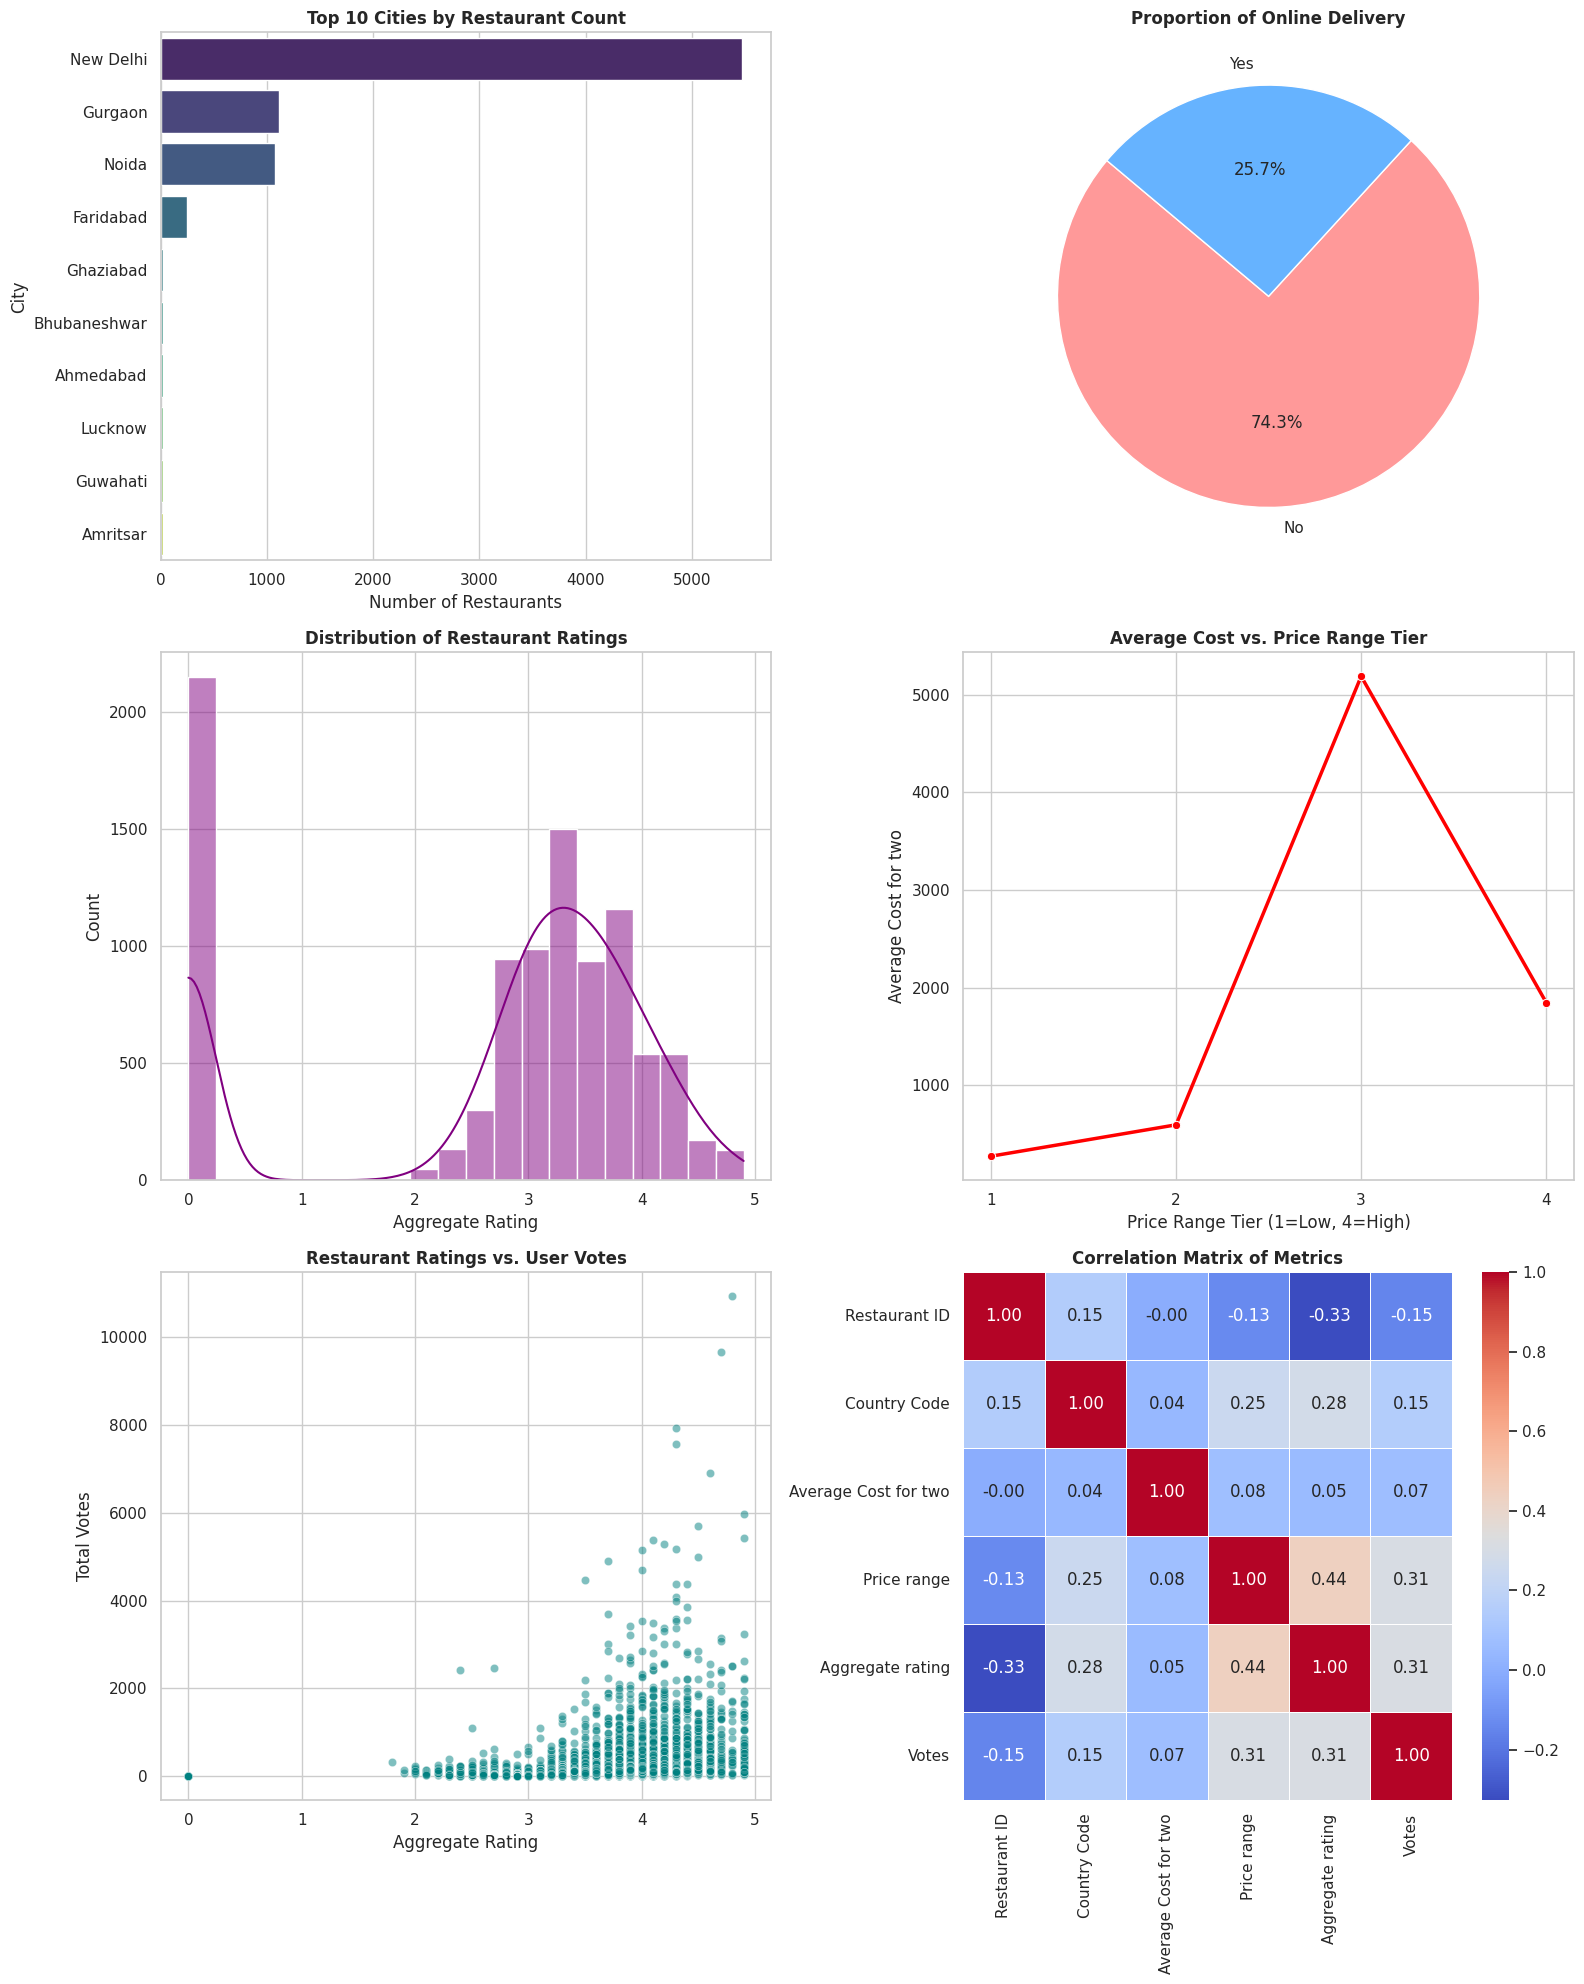

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 20))

# 1. BAR CHART: Top 10 Cities
top_cities = df['City'].value_counts().head(10)
sns.barplot(x=top_cities.values, y=top_cities.index, ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title('Top 10 Cities by Restaurant Count', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Number of Restaurants')
axes[0, 0].set_ylabel('City')

# 2. PIE CHART: Delivery Availability
delivery_counts = df['Has Online delivery'].value_counts()
axes[0, 1].pie(delivery_counts, labels=delivery_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
axes[0, 1].set_title('Proportion of Online Delivery', fontsize=12, fontweight='bold')

# 3. HISTOGRAM: Rating Distribution
valid_ratings = df['Aggregate rating'].dropna()
sns.histplot(valid_ratings, bins=20, kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Distribution of Restaurant Ratings', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Aggregate Rating')
axes[1, 0].set_ylabel('Count')

# 4. LINE CHART: Price Tier Cost
price_cost = df.groupby('Price range')['Average Cost for two'].mean().reset_index()
sns.lineplot(data=price_cost, x='Price range', y='Average Cost for two', marker='o', ax=axes[1, 1], color='red', linewidth=2.5)
axes[1, 1].set_xticks(sorted(df['Price range'].dropna().unique()))
axes[1, 1].set_title('Average Cost vs. Price Range Tier', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Price Range Tier (1=Low, 4=High)')

# 5. SCATTER PLOT: Ratings vs Engagement
sns.scatterplot(data=df, x='Aggregate rating', y='Votes', ax=axes[2, 0], alpha=0.5, color='teal')
axes[2, 0].set_title('Restaurant Ratings vs. User Votes', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Aggregate Rating')
axes[2, 0].set_ylabel('Total Votes')

# 6. HEATMAP: Metric Correlation
numeric_cols = df.select_dtypes(include=[np.number])
numeric_cols = numeric_cols.loc[:, numeric_cols.nunique() > 1]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[2, 1])
axes[2, 1].set_title('Correlation Matrix of Metrics', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

1. Expanding past the big hubs
So, looking at the first bar chart, it’s honestly pretty glaring how jammed all the restaurant listings are into just a few massive cities. The rest of the map is kind of empty. I really think we should start targeting tier-2 cities for expansion. If we start partnering with local chains in those smaller cities now, we can grab that market share before our competitors even get there.

2. Getting offline places onto delivery
The pie chart actually surprised me a bit—a huge chunk of these restaurants don't even offer online delivery through us yet. I mean, that feels like a massive missed opportunity. What if management launched a campaign to offer them, like, heavily reduced commission rates for the first 90 days? Just to get them over the hurdle of signing up. Once they are online, our transaction volume goes up automatically.

3. Fixing the "0.0" rating issue
When I ran the histogram for the ratings, there was this massive, weird spike sitting exactly at a 0.0 rating. I'm assuming these are mostly just new or unrated places that are getting buried. We should probably add a "New & Rising" tab on the app. Maybe we could even incentivize users—like give them a small discount if they are the first person to leave a review for a dormant restaurant to help kickstart the algorithm.

4. A premium tier for the high-end places
Looking at the line chart, once you hit Price Range 3 and 4, the average cost for two just skyrockets. Since those premium orders obviously pull in way higher margins, I was thinking we could lean into that. Maybe we could build an exclusive, high-tier subscription specifically for high-income users? Something that gives them concierge booking or tasting menus to really maximize that high-margin revenue.

5. Gamifying the mid-tier reviews
Lastly... the scatter plot and the heatmap basically confirmed that more user votes strongly correlate with higher aggregate ratings. The popular places get all the engagement. To fix this, I think we need to gamify the review process. If we give users profile badges or loyalty points specifically for reviewing the average, mid-tier restaurants (the ones stuck around 3.0 to 4.0), it would really help build out our data profile and make the whole platform's rating system way more reliable.